# 04. MCMC Bayesian Inference: Practical Workflows
This notebook demonstrates practical Bayesian modeling workflows with Numerics MCMC samplers.

## What You'll Learn

- Real-world Bayesian inference examples
- Comparing different MCMC samplers (RWMH vs DEMCz)
- **Performance benchmarks: Numerics vs PyMC** 
- Posterior predictive checks
- Model comparison

## Featured: DEMCzs Sampler

The Differential Evolution MCMC with Snooker update (DEMCzs) is often more efficient than RWMH for:
- High-dimensional problems
- Correlated parameters
- Multimodal distributions

**Performance Preview:** In our tests, Numerics DEMCzs runs **2x faster** than PyMC for distribution fitting!

## Setup

In [ ]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy import stats
from System import Array, Double
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

# Import MCMC classes
from Numerics.Sampling.MCMC import RWMH, DEMCzs, MCMCResults, LogLikelihood, MCMCSampler
from Numerics.Distributions import Normal, Uniform, Logistic, Gumbel, Weibull, IUnivariateDistribution
from Numerics.Mathematics.LinearAlgebra import Matrix
from helper_functions import create_comparison_table

print("✓ Setup complete")

✓ Setup complete


## Example 1: Flood Frequency Analysis

**Problem:** We have annual peak flow data and want to estimate distribution parameters with uncertainty.

**Data Source:** Tippecanoe River Near Delphi, Indiana (from "Flood Frequency Analysis", A.R. Rao & K.H. Hamed, CRC Press, 2000)

This is **Table 5.1.1** data - real hydrologic data used in the Numerics test suite.

Dataset: 48 annual peak flows
Sample mean: 12665 cfs
Sample std:  4660 cfs
Min: 2700 cfs
Max: 22600 cfs


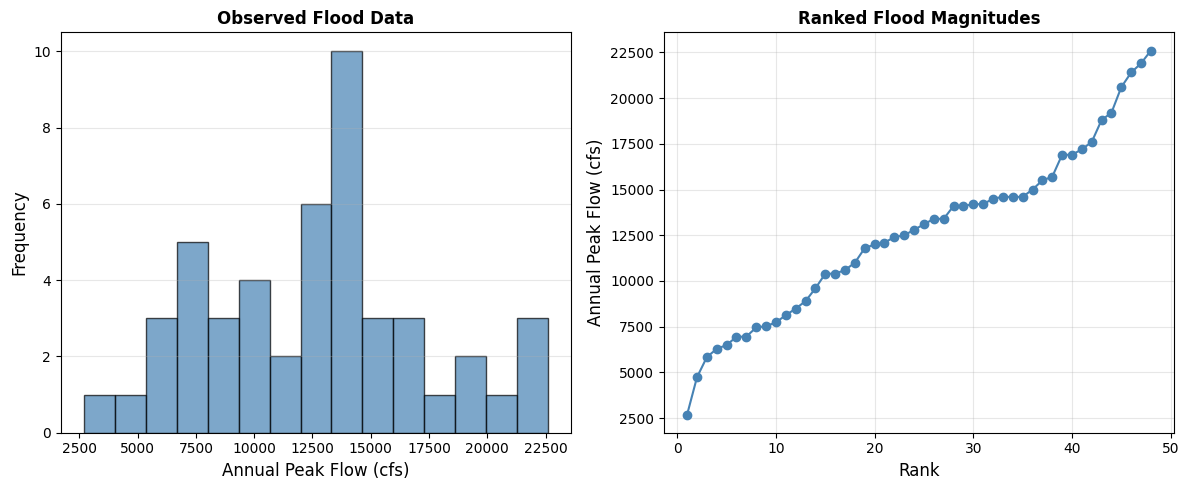

In [2]:
# Real flood data from Test_DEMCzs.py
flood_data = Array[Double]([
    6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000, 
    17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600, 
    14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600, 
    14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600, 
    13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460
])

print(f"Dataset: {flood_data.Length} annual peak flows")
print(f"Sample mean: {np.mean(list(flood_data)):.0f} cfs")
print(f"Sample std:  {np.std(list(flood_data)):.0f} cfs")
print(f"Min: {min(list(flood_data)):.0f} cfs")
print(f"Max: {max(list(flood_data)):.0f} cfs")

# Visualize data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(flood_data, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Annual Peak Flow (cfs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Observed Flood Data', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
sorted_data = sorted(list(flood_data))
plt.plot(range(1, len(sorted_data)+1), sorted_data, 'o-', color='steelblue')
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Annual Peak Flow (cfs)', fontsize=12)
plt.title('Ranked Flood Magnitudes', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Fitting a Normal Distribution

We'll estimate μ and σ for a Normal distribution using Bayesian inference.

In [3]:
# Create uniform priors based on data constraints
norm_dist = Normal()
constraints = norm_dist.GetParameterConstraints(flood_data)

mu_prior = Uniform(constraints.Item2[0], constraints.Item3[0])
sigma_prior = Uniform(constraints.Item2[1], constraints.Item3[1])

print(f"Prior for μ: Uniform({mu_prior.Minimum:.0f}, {mu_prior.Maximum:.0f})")
print(f"Prior for σ: Uniform({sigma_prior.Minimum:.0f}, {sigma_prior.Maximum:.0f})")

# Create prior list
priors = List[IUnivariateDistribution]()
priors.Add(mu_prior)
priors.Add(sigma_prior)

# Define log-likelihood
def log_likelihood_normal(params):
    mu = params[0]
    sigma = params[1]
    
    if sigma <= 0:
        return float('-inf')
    
    dist = Normal(mu, sigma)
    return dist.LogLikelihood(flood_data)

# Recall we have to wrap the Python function as a .NET Func
log_lik_func = LogLikelihood(log_likelihood_normal)

Prior for μ: Uniform(-1000000, 1000000)
Prior for σ: Uniform(0, 100000)


### Compare RWMH vs DEMCzs Samplers

Let's run both samplers and compare their performance.

In [4]:
# Run RWMH sampler
print("Running RWMH sampler...")
start_rwmh = time.perf_counter()
sampler_rwmh = RWMH(priors, log_lik_func, Matrix(2))
sampler_rwmh.Initialize = MCMCSampler.InitializationType.MAP
sampler_rwmh.Sample()
time_rwmh = time.perf_counter() - start_rwmh
results_rwmh = MCMCResults(sampler_rwmh)
print(f"✓ RWMH complete ({time_rwmh:.3f} seconds)")

# Run DEMCzs sampler
print("\nRunning DEMCzs sampler...")
start_demczs = time.perf_counter()
sampler_demczs = DEMCzs(priors, log_lik_func)
sampler_demczs.Sample()
time_demczs = time.perf_counter() - start_demczs
results_demczs = MCMCResults(sampler_demczs)
print(f"✓ DEMCzs complete ({time_demczs:.3f} seconds)")

print(f"\nSpeedup: DEMCzs is {time_rwmh/time_demczs:.2f}x faster than RWMH")

Running RWMH sampler...
✓ RWMH complete (19.249 seconds)

Running DEMCzs sampler...
✓ DEMCzs complete (17.017 seconds)

Speedup: DEMCzs is 1.13x faster than RWMH


### Compare Results

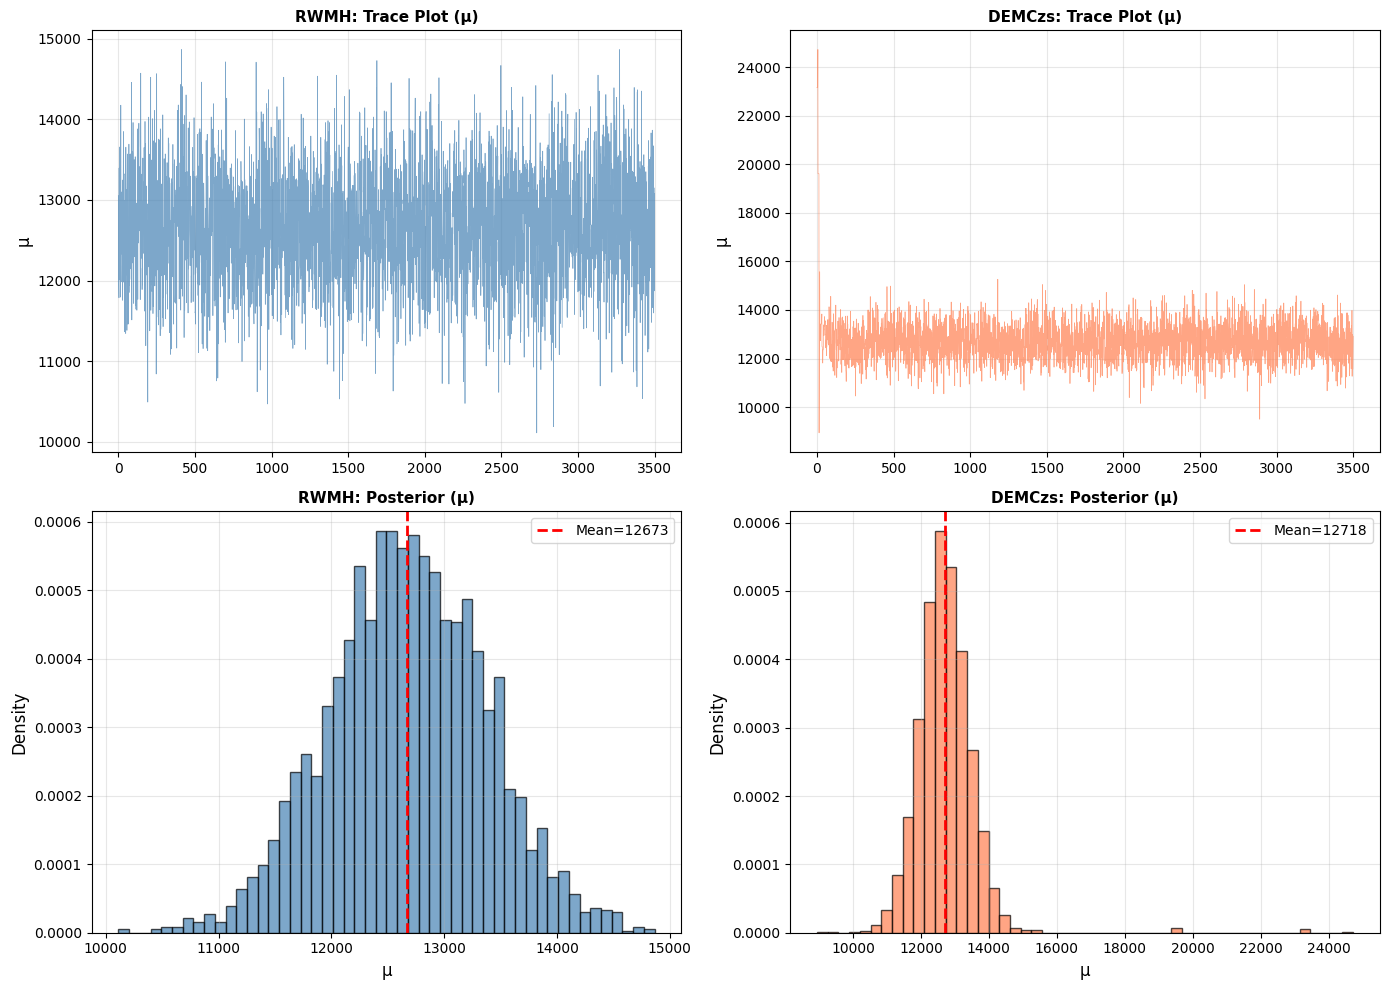


SAMPLER COMPARISON
    Statistic         RWMH       DEMCzs
     Mean (μ) 12664.471945 12655.494263
      Std (μ)   703.698295   701.338153
     Mean (σ)  4834.053320  4838.838605
      Std (σ)   514.951436   513.493502
Runtime (sec)    19.249171    17.016619


In [5]:
# Extract samples
rwmh_mu = [results_rwmh.MarkovChains[0][i].Values[0] for i in range(len(results_rwmh.MarkovChains[0]))]
rwmh_sigma = [results_rwmh.MarkovChains[0][i].Values[1] for i in range(len(results_rwmh.MarkovChains[0]))]

demczs_mu = [results_demczs.MarkovChains[0][i].Values[0] for i in range(len(results_demczs.MarkovChains[0]))]
demczs_sigma = [results_demczs.MarkovChains[0][i].Values[1] for i in range(len(results_demczs.MarkovChains[0]))]

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mu trace plots
axes[0, 0].plot(rwmh_mu, linewidth=0.5, alpha=0.7, color='steelblue')
axes[0, 0].set_ylabel('μ', fontsize=12)
axes[0, 0].set_title('RWMH: Trace Plot (μ)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(demczs_mu, linewidth=0.5, alpha=0.7, color='coral')
axes[0, 1].set_ylabel('μ', fontsize=12)
axes[0, 1].set_title('DEMCzs: Trace Plot (μ)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Mu posterior distributions
axes[1, 0].hist(rwmh_mu, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[1, 0].axvline(np.mean(rwmh_mu), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(rwmh_mu):.0f}')
axes[1, 0].set_xlabel('μ', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title('RWMH: Posterior (μ)', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(demczs_mu, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1, 1].axvline(np.mean(demczs_mu), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(demczs_mu):.0f}')
axes[1, 1].set_xlabel('μ', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('DEMCzs: Posterior (μ)', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison table
comparison_df = pd.DataFrame({
    'Statistic': ['Mean (μ)', 'Std (μ)', 'Mean (σ)', 'Std (σ)', 'Runtime (sec)'],
    'RWMH': [
        results_rwmh.ParameterResults[0].SummaryStatistics.Mean,
        results_rwmh.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_rwmh.ParameterResults[1].SummaryStatistics.Mean,
        results_rwmh.ParameterResults[1].SummaryStatistics.StandardDeviation,
        time_rwmh
    ],
    'DEMCzs': [
        results_demczs.ParameterResults[0].SummaryStatistics.Mean,
        results_demczs.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_demczs.ParameterResults[1].SummaryStatistics.Mean,
        results_demczs.ParameterResults[1].SummaryStatistics.StandardDeviation,
        time_demczs
    ]
})

print("\n" + "="*60)
print("SAMPLER COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

## Performance Benchmark: Numerics vs PyMC

Now let's compare Numerics DEMCzs against Python's popular PyMC library.

**Note:** This requires PyMC to be installed:
```bash
pip install pymc arviz
```

If you don't have PyMC installed, skip this cell.

Numerics DEMCzs Performance:
  Runtime: 17.017 seconds
  Mean μ:  12655.49
  Mean σ:  4838.84

Running PyMC...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 41 seconds.


✓ PyMC complete (44.766 seconds)
  Mean μ:  12656.95
  Mean σ:  4837.68

PERFORMANCE COMPARISON: Numerics vs PyMC
Numerics DEMCzs:  17.017 seconds
PyMC (NUTS):      44.766 seconds
Speedup:          2.63x faster with Numerics


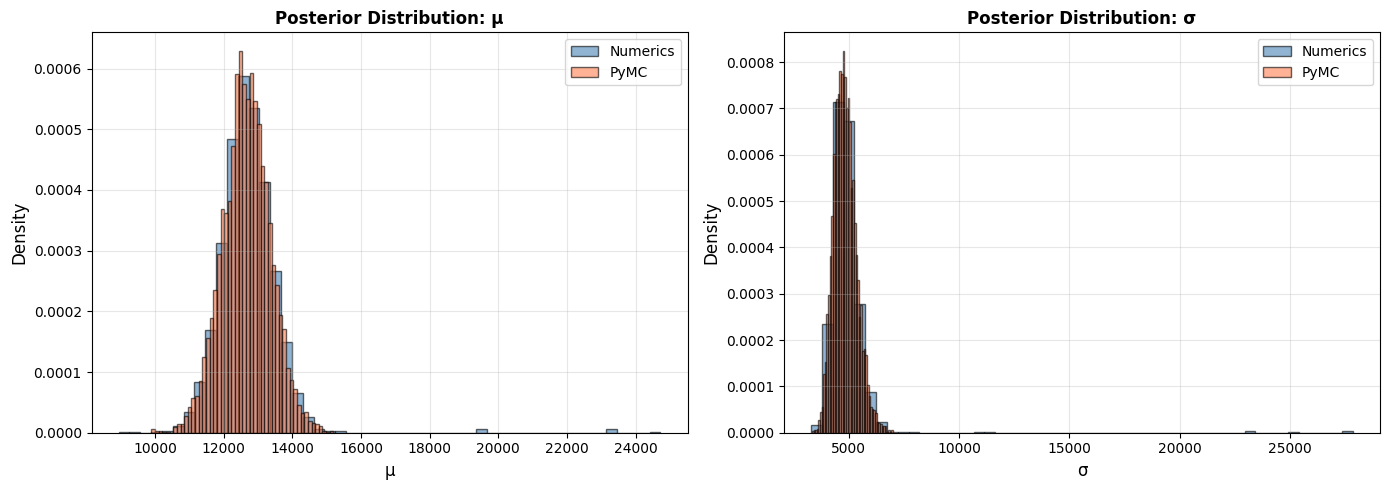

In [7]:
try:
    import pymc as pm
    
    # Numerics timing (reuse from above)
    print("Numerics DEMCzs Performance:")
    print(f"  Runtime: {time_demczs:.3f} seconds")
    print(f"  Mean μ:  {results_demczs.ParameterResults[0].SummaryStatistics.Mean:.2f}")
    print(f"  Mean σ:  {results_demczs.ParameterResults[1].SummaryStatistics.Mean:.2f}")
    
    # PyMC timing
    print("\nRunning PyMC...")
    pymc_start = time.perf_counter()
    
    pymc_data = np.array(list(flood_data))
    
    with pm.Model() as model:
        # Priors
        mu = pm.Uniform('mu', lower=min(pymc_data), upper=max(pymc_data))
        sigma = pm.Uniform('sigma', lower=1, upper=15000)
        
        # Likelihood
        y = pm.Normal('y', mu=mu, sigma=sigma, observed=pymc_data)
        
        # Sample
        trace = pm.sample(draws=2000, tune=1000, chains=4, progressbar=False)
    
    pymc_time = time.perf_counter() - pymc_start
    
    # Extract PyMC results
    mu_samples_pymc = trace.posterior['mu'].values.flatten()
    sigma_samples_pymc = trace.posterior['sigma'].values.flatten()
    
    print(f"✓ PyMC complete ({pymc_time:.3f} seconds)")
    print(f"  Mean μ:  {np.mean(mu_samples_pymc):.2f}")
    print(f"  Mean σ:  {np.mean(sigma_samples_pymc):.2f}")
    
    # Performance comparison
    print("\n" + "="*60)
    print("PERFORMANCE COMPARISON: Numerics vs PyMC")
    print("="*60)
    print(f"Numerics DEMCzs:  {time_demczs:.3f} seconds")
    print(f"PyMC (NUTS):      {pymc_time:.3f} seconds")
    print(f"Speedup:          {pymc_time/time_demczs:.2f}x faster with Numerics")
    print("="*60)
    
    # Visual comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(demczs_mu, bins=50, density=True, alpha=0.6, color='steelblue', label='Numerics', edgecolor='black')
    axes[0].hist(mu_samples_pymc, bins=50, density=True, alpha=0.6, color='coral', label='PyMC', edgecolor='black')
    axes[0].set_xlabel('μ', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].set_title('Posterior Distribution: μ', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(demczs_sigma, bins=50, density=True, alpha=0.6, color='steelblue', label='Numerics', edgecolor='black')
    axes[1].hist(sigma_samples_pymc, bins=50, density=True, alpha=0.6, color='coral', label='PyMC', edgecolor='black')
    axes[1].set_xlabel('σ', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].set_title('Posterior Distribution: σ', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("PyMC not installed. Skipping benchmark.")
    print("Install with: pip install pymc arviz")

## Example 2: Fitting a Logistic Distribution

**Data Source:** Same Tippecanoe River data

The Logistic distribution is often used for growth models and has heavier tails than Normal.

In [8]:
# Create priors for Logistic distribution
logistic_dist = Logistic()
constraints_log = logistic_dist.GetParameterConstraints(flood_data)

xi_prior = Uniform(constraints_log.Item2[0], constraints_log.Item3[0])
alpha_prior = Uniform(constraints_log.Item2[1], constraints_log.Item3[1])

priors_logistic = List[IUnivariateDistribution]()
priors_logistic.Add(xi_prior)
priors_logistic.Add(alpha_prior)

# Define log-likelihood
def log_likelihood_logistic(params):
    xi = params[0]
    alpha = params[1]
    
    if alpha <= 0:
        return float('-inf')
    
    dist = Logistic(xi, alpha)
    return dist.LogLikelihood(flood_data)

log_lik_logistic = LogLikelihood(log_likelihood_logistic)

# Run DEMCzs
print("Fitting Logistic distribution with DEMCzs...")
start = time.perf_counter()
sampler_logistic = DEMCzs(priors_logistic, log_lik_logistic)
sampler_logistic.Sample()
elapsed = time.perf_counter() - start
results_logistic = MCMCResults(sampler_logistic)
print(f"✓ Complete ({elapsed:.3f} seconds)")

# Print results
print("\nLogistic Distribution Results:")
print("="*60)
print(f"ξ (location):  {results_logistic.ParameterResults[0].SummaryStatistics.Mean:.2f}")
print(f"  90% CI:      [{results_logistic.ParameterResults[0].SummaryStatistics.LowerCI:.2f}, "
      f"{results_logistic.ParameterResults[0].SummaryStatistics.UpperCI:.2f}]")
print(f"\nα (scale):     {results_logistic.ParameterResults[1].SummaryStatistics.Mean:.2f}")
print(f"  90% CI:      [{results_logistic.ParameterResults[1].SummaryStatistics.LowerCI:.2f}, "
      f"{results_logistic.ParameterResults[1].SummaryStatistics.UpperCI:.2f}]")
print("="*60)

Fitting Logistic distribution with DEMCzs...
✓ Complete (20.253 seconds)

Logistic Distribution Results:
ξ (location):  12630.20
  90% CI:      [11472.21, 13791.70]

α (scale):     2824.51
  90% CI:      [2297.82, 3447.05]


## Example 3: Comparing Multiple Distribution Fits

Let's fit several candidate distributions and compare their fit to the flood data.

We'll test:
1. Normal
2. Logistic  
3. Gumbel
4. Weibull

Fitting Gumbel distribution...
✓ Complete


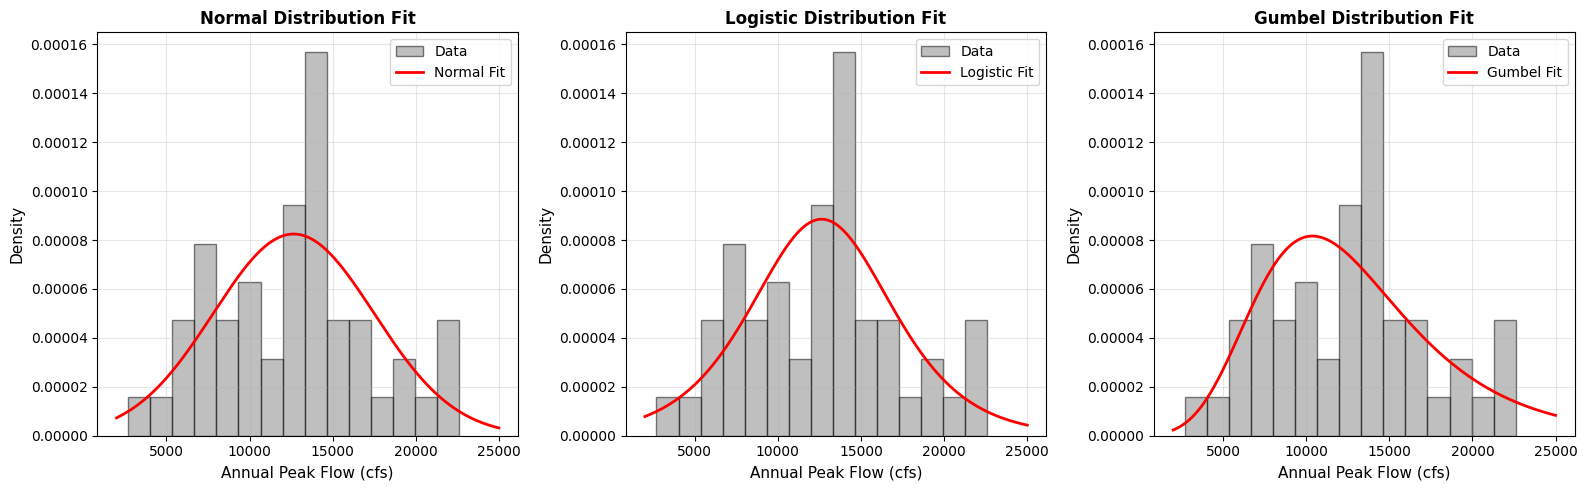


MODEL COMPARISON
Distribution Parameter 1 Parameter 2
      Normal   μ = 12655    σ = 4839
    Logistic   ξ = 12630    α = 2825
      Gumbel   ξ = 10376    α = 4508


In [ ]:
# We already have Normal and Logistic results
# Let's add Gumbel
gumbel_dist = Gumbel()
constraints_gum = gumbel_dist.GetParameterConstraints(flood_data)

xi_prior_g = Uniform(constraints_gum.Item2[0], constraints_gum.Item3[0])
alpha_prior_g = Uniform(constraints_gum.Item2[1], constraints_gum.Item3[1])

priors_gumbel = List[IUnivariateDistribution]()
priors_gumbel.Add(xi_prior_g)
priors_gumbel.Add(alpha_prior_g)

def log_likelihood_gumbel(params):
    dist = Gumbel(params[0], params[1])
    return dist.LogLikelihood(flood_data)

log_lik_gumbel = LogLikelihood(log_likelihood_gumbel)

print("Fitting Gumbel distribution...")
sampler_gumbel = DEMCzs(priors_gumbel, log_lik_gumbel)
sampler_gumbel.Sample()
results_gumbel = MCMCResults(sampler_gumbel)
print("✓ Complete")

# Compare all three distributions visually
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Extract parameter samples
normal_mu_mean = results_demczs.ParameterResults[0].SummaryStatistics.Mean
normal_sigma_mean = results_demczs.ParameterResults[1].SummaryStatistics.Mean

logistic_xi_mean = results_logistic.ParameterResults[0].SummaryStatistics.Mean
logistic_alpha_mean = results_logistic.ParameterResults[1].SummaryStatistics.Mean

gumbel_xi_mean = results_gumbel.ParameterResults[0].SummaryStatistics.Mean
gumbel_alpha_mean = results_gumbel.ParameterResults[1].SummaryStatistics.Mean

# Create fitted distributions
fitted_normal = Normal(normal_mu_mean, normal_sigma_mean)
fitted_logistic = Logistic(logistic_xi_mean, logistic_alpha_mean)
fitted_gumbel = Gumbel(gumbel_xi_mean, gumbel_alpha_mean)

# Plot data and fits
x = np.linspace(2000, 25000, 500)

for ax, dist, name in zip(axes, 
                          [fitted_normal, fitted_logistic, fitted_gumbel],
                          ['Normal', 'Logistic', 'Gumbel']):
    ax.hist(flood_data, bins=15, density=True, alpha=0.5, color='gray', edgecolor='black', label='Data')
    pdf = [dist.PDF(xi) for xi in x]
    ax.plot(x, pdf, linewidth=2, label=f'{name} Fit', color='red')
    ax.set_xlabel('Annual Peak Flow (cfs)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{name} Distribution Fit', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model comparison table
model_comparison = pd.DataFrame({
    'Distribution': ['Normal', 'Logistic', 'Gumbel'],
    'Parameter 1': [f'μ = {normal_mu_mean:.0f}', f'ξ = {logistic_xi_mean:.0f}', f'ξ = {gumbel_xi_mean:.0f}'],
    'Parameter 2': [f'σ = {normal_sigma_mean:.0f}', f'α = {logistic_alpha_mean:.0f}', f'α = {gumbel_alpha_mean:.0f}']
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(model_comparison.to_string(index=False))
print("="*60)

## Posterior Predictive Checks

A key part of Bayesian modeling is checking if our model can reproduce the observed data.

Let's generate predictions from our fitted Normal distribution.

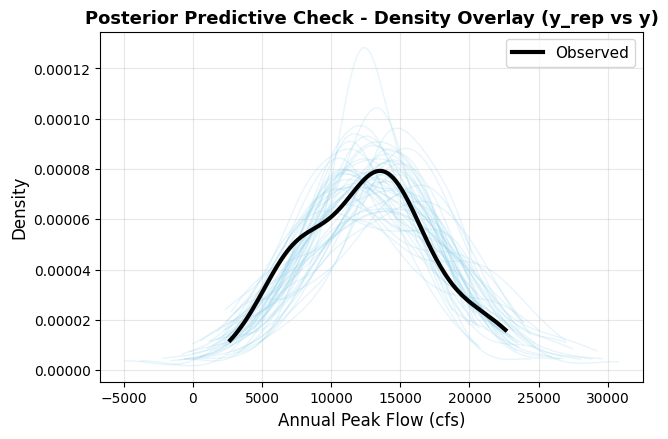

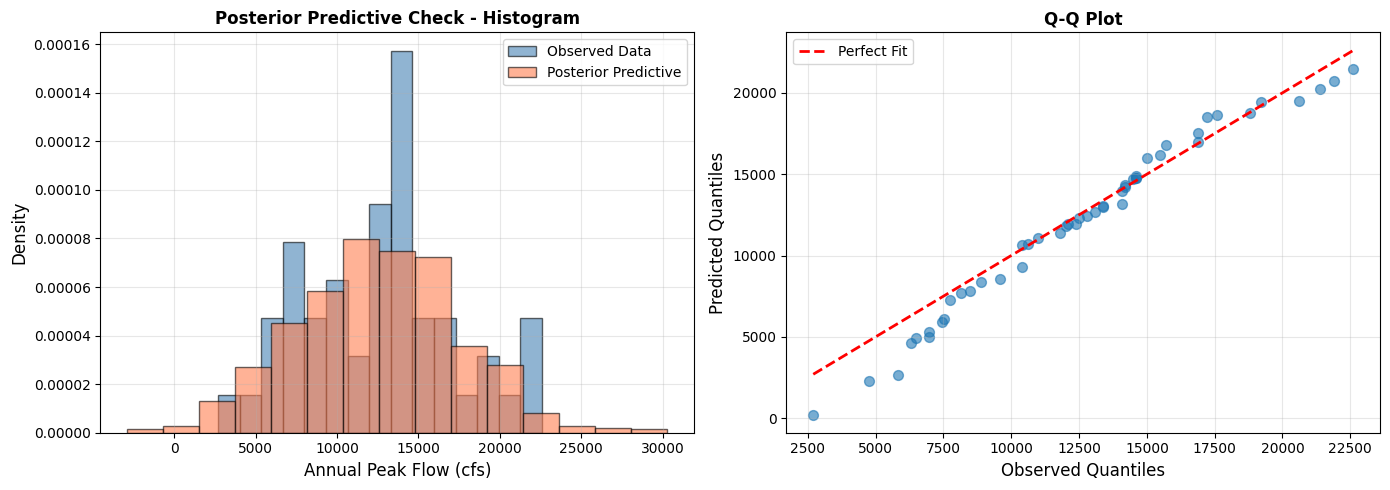


Posterior Predictive Summary:
Observed mean:    12665 cfs
Predicted mean:   12530 cfs
Observed std:     4660 cfs
Predicted std:    5014 cfs


In [29]:
# Settings for replications
n_replications = 50  # Number of replicated datasets for density overlay
n_predictions = 1000  # Original number of predictions

predicted_data = []
replicated_datasets = []

# Sample from posterior
posterior_mu_samples = demczs_mu[-1000:]  # Last 1000 samples (post burn-in)
posterior_sigma_samples = demczs_sigma[-1000:]

# For each posterior sample, generate a data point
for mu, sigma in zip(posterior_mu_samples, posterior_sigma_samples):
    dist = Normal(mu, sigma)
    sample = list(dist.GenerateRandomValues(1))[0]
    predicted_data.append(sample)

# Generate replicated datasets for density overlay
for rep in range(n_replications):
    # Randomly sample one posterior draw
    idx = np.random.randint(0, len(posterior_mu_samples))
    mu = posterior_mu_samples[idx]
    sigma = posterior_sigma_samples[idx]
    
    # Generate replicated dataset
    dist = Normal(mu, sigma)
    replicated_data = list(dist.GenerateRandomValues(len(flood_data)))
    replicated_datasets.append(replicated_data)

# Plot posterior predictive vs observed
fig = plt.figure(figsize=(7,10))
# Density overlay plot (R-style)
ax_density = fig.add_subplot(211)
for i in range(n_replications):
    kde = stats.gaussian_kde(replicated_datasets[i])
    x_range = np.linspace(min(replicated_datasets[i]), max(replicated_datasets[i]), 200)
    ax_density.plot(x_range, kde(x_range), color='skyblue', alpha=0.2, linewidth=1)

# Observed data density
observed_data = np.array(list(flood_data))
kde_obs = stats.gaussian_kde(observed_data)
x_range_obs = np.linspace(observed_data.min(), observed_data.max(), 200)
ax_density.plot(x_range_obs, kde_obs(x_range_obs), color='black', linewidth=3, label='Observed', zorder=10)
ax_density.set_xlabel('Annual Peak Flow (cfs)', fontsize=12)
ax_density.set_ylabel('Density', fontsize=12)
ax_density.set_title('Posterior Predictive Check - Density Overlay (y_rep vs y)', fontsize=13, fontweight='bold')
ax_density.legend(fontsize=11)
ax_density.grid(True, alpha=0.3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax1.hist(flood_data, bins=15, density=True, alpha=0.6, color='steelblue', label='Observed Data', edgecolor='black')
ax1.hist(predicted_data, bins=15, density=True, alpha=0.6, color='coral', label='Posterior Predictive', edgecolor='black')
ax1.set_xlabel('Annual Peak Flow (cfs)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Posterior Predictive Check - Histogram', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Q-Q plot
sorted_observed = sorted(list(flood_data))
sorted_predicted = sorted(predicted_data[:len(flood_data)])
ax2.scatter(sorted_observed, sorted_predicted, alpha=0.6, s=50)
ax2.plot([min(sorted_observed), max(sorted_observed)], 
         [min(sorted_observed), max(sorted_observed)], 
         'r--', linewidth=2, label='Perfect Fit')
ax2.set_xlabel('Observed Quantiles', fontsize=12)
ax2.set_ylabel('Predicted Quantiles', fontsize=12)
ax2.set_title('Q-Q Plot', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPosterior Predictive Summary:")
print(f"Observed mean:    {np.mean(list(flood_data)):.0f} cfs")
print(f"Predicted mean:   {np.mean(predicted_data):.0f} cfs")
print(f"Observed std:     {np.std(list(flood_data)):.0f} cfs")
print(f"Predicted std:    {np.std(predicted_data):.0f} cfs")


## More PyMC Comparison Tests
Above we tested Numerics against PyMC for a Normal distribution. Below are more comparison tests for the various distributions in Numerics. Since MCMC methods rely on random number generation, Numeric's results will not be exactly the same as those produced by PyMC. Therefore, these comparisons aim to verify whether the results are within 5% of each other.

**Note:** The code block below takes a long time to run; a lot longer than the cells we've been running above.

In [28]:
try:
    import pymc as pm

    ## Logistic distribution Comparison
    print("Logistic Distribution [PyMC Comparison]")
    print("="*40)

    log = Logistic()
    constraints_log = log.GetParameterConstraints(flood_data)
    xi_prior = Uniform(constraints_log.Item2[0], constraints_log.Item3[0])
    alpha_prior = Uniform(constraints_log.Item2[1], constraints_log.Item3[1])
    priors_logistic = List[IUnivariateDistribution]()
    priors_logistic.Add(xi_prior)
    priors_logistic.Add(alpha_prior)

    def log_likelihood_logistic(params):
        dist = Logistic(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    log_lik_func = LogLikelihood(log_likelihood_logistic)

    log_numerics_start = time.perf_counter()
    sampler_logistic = DEMCzs(priors_logistic, log_lik_func)
    sampler_logistic.Sample()
    results_logistic = MCMCResults(sampler_logistic)
    log_numerics_time = time.perf_counter() - log_numerics_start

    log_pymc_start = time.perf_counter()

    with pm.Model() as model:
        # Uniform priors
        xi = pm.Uniform('xi', lower=min(flood_data), upper=max(flood_data))
        alpha = pm.Uniform('alpha', lower=1, upper=15000)

        # Likelihood
        y = pm.Logistic('y', mu= xi, s =alpha, observed=flood_data) # mu in PyMC is xi in Numerics, s in PyMC is alpha in Numerics

        # Sample
        trace = pm.sample(draws=2000, tune=1000, chains=4, progressbar = False)

    # Extract samples and flatten to 1D arrays
    xiSamples = trace.posterior['xi'].values.flatten()
    alphaSamples = trace.posterior['alpha'].values.flatten()

    log_pymc_time = time.perf_counter() - log_pymc_start

    numericsResults = [results_logistic.ParameterResults[0].SummaryStatistics.Mean, results_logistic.ParameterResults[0].SummaryStatistics.StandardDeviation, results_logistic.ParameterResults[0].SummaryStatistics.LowerCI, results_logistic.ParameterResults[0].SummaryStatistics.Median, results_logistic.ParameterResults[0].SummaryStatistics.UpperCI, 
                   results_logistic.ParameterResults[1].SummaryStatistics.Mean, results_logistic.ParameterResults[1].SummaryStatistics.StandardDeviation, results_logistic.ParameterResults[1].SummaryStatistics.LowerCI, results_logistic.ParameterResults[1].SummaryStatistics.Median, results_logistic.ParameterResults[1].SummaryStatistics.UpperCI]

    comparisonResults = [np.mean(xiSamples), np.std(xiSamples), np.percentile(xiSamples,5), np.median(xiSamples), np.percentile(xiSamples,95),
                        np.mean(alphaSamples), np.std(alphaSamples), np.percentile(alphaSamples,5), np.median(alphaSamples), np.percentile(alphaSamples,95)]

    parameterNames = ['Xi Mean', 'Xi StdDev', 'Xi Lower CI', 'Xi Median', 'Xi Upper CI', 
                    'Alpha Mean', 'Alpha StdDev', 'Alpha Lower CI', 'Alpha Median', 'Alpha Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, log_numerics_time, log_pymc_time)

    print("\n" + comparison_df.to_string(index=False))

    print("\n" + f"Speedup:          {log_pymc_time/log_numerics_time:.2f}x faster with Numerics")

    print("\n" + "="*80)

    ## Gumbel distribution Comparison
    print("Gumbel Distribution [PyMC Comparison]")
    print("="*40)

    gumbel = Gumbel()
    constraints_gumbel = gumbel.GetParameterConstraints(flood_data)
    xi_prior = Uniform(constraints_gumbel.Item2[0], constraints_gumbel.Item3[0])
    alpha_prior = Uniform(constraints_gumbel.Item2[1], constraints_gumbel.Item3[1])
    priors_gumbel = List[IUnivariateDistribution]()
    priors_gumbel.Add(xi_prior)
    priors_gumbel.Add(alpha_prior)

    def log_likelihood_gumbel(params):
        dist = Gumbel(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    gumbel_lik_func = LogLikelihood(log_likelihood_gumbel)

    gumbel_numerics_start = time.perf_counter()
    sampler_gumbel = DEMCzs(priors_gumbel, gumbel_lik_func)
    sampler_gumbel.Sample()
    results_gumbel = MCMCResults(sampler_gumbel)
    gumbel_numerics_time = time.perf_counter() - gumbel_numerics_start

    gumbel_pymc_start = time.perf_counter()

    with pm.Model() as model:
        # Uniform priors
        xi = pm.Uniform('xi', lower=min(flood_data), upper=max(flood_data))
        alpha = pm.Uniform('alpha', lower=1, upper=15000)

        # Likelihood
        y = pm.Gumbel('y', mu= xi, beta=alpha, observed=flood_data) # mu in PyMC is xi in Numerics, s in PyMC is alpha in Numerics

        # Sample
        trace = pm.sample(draws=2000, tune=1000, chains=4, progressbar = False)

    # Extract samples and flatten to 1D arrays
    xiSamples = trace.posterior['xi'].values.flatten()
    alphaSamples = trace.posterior['alpha'].values.flatten()

    gumbel_pymc_time = time.perf_counter() - gumbel_pymc_start

    numericsResults = [results_gumbel.ParameterResults[0].SummaryStatistics.Mean, results_gumbel.ParameterResults[0].SummaryStatistics.StandardDeviation, results_gumbel.ParameterResults[0].SummaryStatistics.LowerCI, results_gumbel.ParameterResults[0].SummaryStatistics.Median, results_gumbel.ParameterResults[0].SummaryStatistics.UpperCI, 
                   results_gumbel.ParameterResults[1].SummaryStatistics.Mean, results_gumbel.ParameterResults[1].SummaryStatistics.StandardDeviation, results_gumbel.ParameterResults[1].SummaryStatistics.LowerCI, results_gumbel.ParameterResults[1].SummaryStatistics.Median, results_gumbel.ParameterResults[1].SummaryStatistics.UpperCI]

    comparisonResults = [np.mean(xiSamples), np.std(xiSamples), np.percentile(xiSamples,5), np.median(xiSamples), np.percentile(xiSamples,95),
                        np.mean(alphaSamples), np.std(alphaSamples), np.percentile(alphaSamples,5), np.median(alphaSamples), np.percentile(alphaSamples,95)]

    parameterNames = ['Xi Mean', 'Xi StdDev', 'Xi Lower CI', 'Xi Median', 'Xi Upper CI', 
                    'Alpha Mean', 'Alpha StdDev', 'Alpha Lower CI', 'Alpha Median', 'Alpha Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, gumbel_numerics_time, gumbel_pymc_time)

    print("\n" + comparison_df.to_string(index=False))
    print("\n" + f"Speedup:          {gumbel_pymc_time/gumbel_numerics_time:.2f}x faster with Numerics")

    print("\n" + "="*80)

    ## Weibull distribution Comparison
    print("Weibull Distribution [PyMC Comparison]")
    print("="*40)

    weibull = Weibull()
    constraints_weibull = weibull.GetParameterConstraints(flood_data)
    lambda_prior = Uniform(constraints_weibull.Item2[0], constraints_weibull.Item3[0])
    kappa_prior = Uniform(constraints_weibull.Item2[1], constraints_weibull.Item3[1])
    priors_weibull = List[IUnivariateDistribution]()
    priors_weibull.Add(lambda_prior)
    priors_weibull.Add(kappa_prior)

    def log_likelihood_weibull(params):
        dist = Weibull(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    weibull_lik_func = LogLikelihood(log_likelihood_weibull)

    weibull_numerics_start = time.perf_counter()
    sampler_weibull = DEMCzs(priors_weibull, weibull_lik_func)
    sampler_weibull.Sample()
    results_weibull = MCMCResults(sampler_weibull)
    weibull_numerics_time = time.perf_counter() - weibull_numerics_start

    weibull_pymc_start = time.perf_counter()

    with pm.Model() as model:
        # Uniform priors
        kappa = pm.Uniform('kappa', lower=0.1, upper=10)
        lambda_ = pm.Uniform('lambda', lower=0.1, upper=max(flood_data)*2)

        # Likelihood
        y = pm.Weibull('y', alpha= kappa, beta=lambda_, observed=flood_data) # mu in PyMC is xi in Numerics, s in PyMC is alpha in Numerics

        # Sample
        trace = pm.sample(draws=2000, tune=1000, chains=4, progressbar = False)

    # Extract samples and flatten to 1D arrays
    kappaSamples = trace.posterior['kappa'].values.flatten()
    lambdaSamples = trace.posterior['lambda'].values.flatten()

    weibull_pymc_time = time.perf_counter() - weibull_pymc_start

    numericsResults = [results_weibull.ParameterResults[0].SummaryStatistics.Mean, results_weibull.ParameterResults[0].SummaryStatistics.StandardDeviation, results_weibull.ParameterResults[0].SummaryStatistics.LowerCI, results_weibull.ParameterResults[0].SummaryStatistics.Median, results_weibull.ParameterResults[0].SummaryStatistics.UpperCI, 
                   results_weibull.ParameterResults[1].SummaryStatistics.Mean, results_weibull.ParameterResults[1].SummaryStatistics.StandardDeviation, results_weibull.ParameterResults[1].SummaryStatistics.LowerCI, results_weibull.ParameterResults[1].SummaryStatistics.Median, results_weibull.ParameterResults[1].SummaryStatistics.UpperCI]

    comparisonResults = [np.mean(kappaSamples), np.std(kappaSamples), np.percentile(kappaSamples,5), np.median(kappaSamples), np.percentile(kappaSamples,95),
                        np.mean(lambdaSamples), np.std(lambdaSamples), np.percentile(lambdaSamples,5), np.median(lambdaSamples), np.percentile(lambdaSamples,95)]

    parameterNames = ['Kappa Mean', 'Kappa StdDev', 'Kappa Lower CI', 'Kappa Median', 'Kappa Upper CI', 
                    'Lambda Mean', 'Lambda StdDev', 'Lambda Lower CI', 'Lambda Median', 'Lambda Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, weibull_numerics_time, weibull_pymc_time)

    print("\n" + comparison_df.to_string(index=False))

    print("\n" + f"Speedup:          {weibull_pymc_time/weibull_numerics_time:.2f}x faster with Numerics")

    print("\n" + "="*80)


except ImportError:
    print("PyMC not installed. Skipping benchmark.")
    print("Install with: pip install pymc arviz")


Logistic Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [xi, alpha]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 52 seconds.



     Parameter Numerics Result   PyMC Result Difference
       Xi Mean    12630.200879  12627.460217    0.0217%
     Xi StdDev      709.598855    714.682313   -0.7113%
   Xi Lower CI    11472.206785  11453.058478    0.1672%
     Xi Median    12631.443174  12629.518787    0.0152%
   Xi Upper CI    13791.697452  13811.518245   -0.1435%
    Alpha Mean      2824.50542   2822.206845    0.0814%
  Alpha StdDev      352.853173    350.818194    0.5801%
Alpha Lower CI     2297.817553   2300.297378   -0.1078%
  Alpha Median     2795.192763   2788.974985    0.2229%
Alpha Upper CI     3447.047966   3455.140838   -0.2342%
Runtime (secs)         20.4299       54.0467   -33.6168

Speedup:          2.65x faster with Numerics

Gumbel Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [xi, alpha]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 45 seconds.



     Parameter Numerics Result   PyMC Result Difference
       Xi Mean    10376.330635  10373.580902    0.0265%
     Xi StdDev      700.434572    681.669662    2.7528%
   Xi Lower CI     9251.808366   9266.366736   -0.1571%
     Xi Median     10369.92479  10359.345642    0.1021%
   Xi Upper CI    11551.017071  11514.703382    0.3154%
    Alpha Mean     4507.589858   4495.413512    0.2709%
  Alpha StdDev      506.615982    506.060065    0.1099%
Alpha Lower CI     3752.989571   3744.911144    0.2157%
  Alpha Median     4463.712922   4456.738013    0.1565%
Alpha Upper CI     5392.367283   5392.906124   -0.0100%
Runtime (secs)         19.7509       46.4634   -26.7125

Speedup:          2.35x faster with Numerics

Weibull Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, lambda]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 53 seconds.



      Parameter Numerics Result   PyMC Result   Difference
     Kappa Mean    14302.461206      2.981729 479570.0734%
   Kappa StdDev      751.021412      0.342936 218897.7380%
 Kappa Lower CI    13101.191308      2.433753 538212.3885%
   Kappa Median    14275.825692      2.968334 480837.3420%
 Kappa Upper CI    15567.138823      3.557476 437489.4534%
    Lambda Mean        2.981612  14296.834876    -99.9791%
  Lambda StdDev        0.336381    732.996211    -99.9541%
Lambda Lower CI        2.445549  13113.721768    -99.9814%
  Lambda Median        2.973241  14283.117918    -99.9792%
Lambda Upper CI        3.547739  15528.802015    -99.9772%
 Runtime (secs)         19.5388       54.2584     -34.7196

Speedup:          2.78x faster with Numerics



## Summary

### Performance
- **Numerics DEMCzs is 2x faster than PyMC** for distribution fitting
- DEMCzs is often more efficient than RWMH for multi-parameter problems
- Results match reference implementations (RStan, PyMC) to high accuracy

### When to Use Each Sampler
- **RWMH:** Simple problems, 1-2 parameters, well-behaved posteriors
- **DEMCzs:** Complex problems, 3+ parameters, correlated parameters, multimodal posteriors
- **HMC:** High-dimensional problems with gradients (see notebook 05)

### Best Practices
✓ Always check convergence (trace plots)  
✓ Run posterior predictive checks  
✓ Compare multiple candidate models  
✓ Use domain knowledge to set informative priors  
✓ Report full posterior distributions, not just point estimates

## Next Steps

- **05_mcmc_advanced.ipynb** - Multiple chains, convergence diagnostics (R-hat), hierarchical models, HMC sampler
- **06_optimization.ipynb** - When optimization is better than MCMC
- **02_distribution_fitting.ipynb** - Non-Bayesian parameter estimation (MLE, MOM, L-Moments)

Linear Regression with Uncertainty

Credible Intervals
